# DiffKD+ : Knowledge Diffusion for Distillation
### Tiny-ImageNet Edition → ResNet-50 Teacher → ResNet-34 Student

**Paper:** [Knowledge Diffusion for Distillation, NeurIPS 2023](https://arxiv.org/abs/2305.15712)  
**Dataset:** Tiny-ImageNet-200 (200 classes, 100k images, 64×64 px)  
**Hardware:** 2× NVIDIA Tesla T4  

---

## What Changed vs Previous Run

| Item | Previous | This Run | Reason |
|------|----------|----------|---------|
| Dataset | ImageNet-Mini (34k, 1000 cls) | **Tiny-ImageNet (100k, 200 cls)** | 3× more data, ~6× more per class |
| Student | ResNet-18 (11.7M) | **ResNet-34 (21.8M)** | Richer features, closer to teacher |
| Augmentation | RandAugment + RE | **+ MixUp (α=0.4)** | Smooth boundaries in low-data regime |
| Teacher prep | ImageNet pretrained only | **+ 10-epoch fine-tune on Tiny-IN** | Aligns teacher features to our data |
| Epochs | 100 | **150** | Tiny-ImageNet needs more passes |
| Peak LR | 0.05 | **0.04** | Larger student → more stable LR |
| Save frequency | every 5 epochs | **every 2 epochs** | Safer against session timeouts |

---

## Three Novelties (unchanged from original DiffKD+)

| # | Novelty | Description |
|---|---------|-------------|
| **N1** | **CosKD Loss** | Direction-aware cosine distillation instead of MSE; scale-invariant |
| **N2** | **EMA Teacher Latent** | Exponential moving average smooths diffusion training target |
| **N3** | **Curriculum Noise** | Timestep anneals T_init→T_final matching student convergence |

---
## Step 1 — Install Dependencies

In [1]:
!pip install timm --quiet

---
## Step 2 — Imports

In [2]:
import os, math, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_GPUS = torch.cuda.device_count()

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"Num GPUs : {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch  : 2.10.0+cu128
Device   : cuda
Num GPUs : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


---
## Step 3 — Configuration

**All hyper-parameters are in one place. Edit only this cell to change anything.**

In [3]:
# ── Paths ─────────────────────────────────────────────────────
# Kaggle dataset: https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet
DATA_DIR    = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"
WORKING_DIR = "/kaggle/working"
CKPT_DIR    = os.path.join(WORKING_DIR, "checkpoints")
CSV_PATH    = os.path.join(WORKING_DIR, "training_history.csv")
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Image / Data ──────────────────────────────────────────────
IMAGE_SIZE   = 64          # Tiny-ImageNet native resolution
NUM_CLASSES  = 200         # Tiny-ImageNet has 200 classes
BATCH_SIZE   = 256 * max(NUM_GPUS, 1)   # 512 total on 2xT4 (64px images are cheap)
NUM_WORKERS  = 4

# ── Training ──────────────────────────────────────────────────
EPOCHS        = 150
BASE_LR       = 0.04
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
MIXUP_ALPHA   = 0.4        # MixUp interpolation strength; 0 = disable

# ── Teacher fine-tuning on Tiny-ImageNet ──────────────────────
FINETUNE_TEACHER = False    # set False if you already have a fine-tuned teacher ckpt
FINETUNE_EPOCHS  = 10
FINETUNE_LR      = 1e-4
TEACHER_CKPT = "/kaggle/input/models/usman191/v2-3-teacherft/other/default/1/teacher_finetuned.pth"
# TEACHER_CKPT     = os.path.join(CKPT_DIR, "teacher_finetuned.pth")

# ── DiffKD+ hyper-parameters ──────────────────────────────────
AE_LATENT_CH   = 128
DIFF_STEPS     = 5         # DDIM reverse steps at inference
DIFF_TRAIN_T   = 1000      # max forward-process timesteps
KD_TEMPERATURE = 2.0

# ── Loss weights ──────────────────────────────────────────────
LAMBDA_CE      = 1.0
LAMBDA_KL      = 0.5
LAMBDA_DIFF    = 0.5
LAMBDA_AE      = 0.5
LAMBDA_DIFFKD  = 1.0

# ── N2: EMA decay ─────────────────────────────────────────────
EMA_DECAY      = 0.999

# ── N3: Curriculum noise schedule ─────────────────────────────
CURR_T_INIT    = 800
CURR_T_FINAL   = 200

# ── Checkpointing ─────────────────────────────────────────────
SAVE_EVERY     = 2         # save every 2 epochs (safer than 5)
VAL_EVERY      = 5
RESUME_CKPT    = "/kaggle/input/models/usman191/v2-3-checkpoint132/other/default/1/epoch_132.pth"      # e.g. CKPT_DIR + "/epoch_050.pth"

# ── Feature channel dims ──────────────────────────────────────
T_FEAT_CH = 2048           # ResNet-50 layer4 output
S_FEAT_CH = 512            # ResNet-34 layer4 output (same as ResNet-18)

print("Config loaded.")
print(f"Batch size : {BATCH_SIZE} total ({BATCH_SIZE//max(NUM_GPUS,1)} per GPU)")
print(f"Epochs     : {EPOCHS}")

Config loaded.
Batch size : 512 total (256 per GPU)
Epochs     : 150


---
## Step 4 — Data Loaders (Tiny-ImageNet)

Tiny-ImageNet has a quirky validation folder structure (flat with annotation files).  
This cell handles that automatically.

In [4]:
import shutil

def fix_tinyimagenet_val(val_dir_src):
    """
    Kaggle /kaggle/input is read-only, so we copy val to /kaggle/working
    and reorganise it there. Returns the path to the usable val directory.
    """
    val_dir_dst = "/kaggle/working/val_organised"

    # If already done in a previous run, reuse it
    if os.path.exists(val_dir_dst) and len(os.listdir(val_dir_dst)) > 0:
        print(f"Val folder already organised at {val_dir_dst}")
        return val_dir_dst

    ann_file   = os.path.join(val_dir_src, "val_annotations.txt")
    images_dir = os.path.join(val_dir_src, "images")

    if not os.path.exists(ann_file):
        # Already class-structured — just return source path
        print("Val folder already class-structured, using source directly.")
        return val_dir_src

    print("Copying and reorganising val folder to /kaggle/working ...")
    os.makedirs(val_dir_dst, exist_ok=True)

    with open(ann_file) as f:
        for line in f:
            parts   = line.strip().split('\t')
            img     = parts[0]
            cls_id  = parts[1]
            cls_dir = os.path.join(val_dir_dst, cls_id)
            os.makedirs(cls_dir, exist_ok=True)
            src = os.path.join(images_dir, img)
            dst = os.path.join(cls_dir, img)
            if os.path.exists(src) and not os.path.exists(dst):
                shutil.copy2(src, dst)

    print(f"Done. Val organised at {val_dir_dst}")
    return val_dir_dst


train_dir = os.path.join(DATA_DIR, "train")
val_dir   = fix_tinyimagenet_val(os.path.join(DATA_DIR, "val"))

# ── Transforms ────────────────────────────────────────────────
# Note: Tiny-ImageNet is 64×64. We use 56×56 crop for training.
train_transform = transforms.Compose([
    transforms.RandomCrop(56, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.4802, 0.4481, 0.3975],
                         [0.2302, 0.2265, 0.2262]),  # Tiny-ImageNet stats
    transforms.RandomErasing(p=0.25),
])

val_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(56),
    transforms.ToTensor(),
    transforms.Normalize([0.4802, 0.4481, 0.3975],
                         [0.2302, 0.2265, 0.2262]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)

print(f"Classes      : {len(train_dataset.classes)}")
print(f"Train images : {len(train_dataset):,}")
print(f"Val images   : {len(val_dataset):,}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    drop_last=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True
)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Copying and reorganising val folder to /kaggle/working ...
Done. Val organised at /kaggle/working/val_organised
Classes      : 200
Train images : 100,000
Val images   : 10,000
Train batches: 195 | Val batches: 20


---
## Step 5 — Teacher & Student Models

In [5]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Teacher: ResNet-50 pretrained on ImageNet-1K ──────────────
teacher = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# Replace final FC for 200 classes
teacher.fc = nn.Linear(2048, NUM_CLASSES)
teacher = teacher.to(DEVICE)

# ── Student: ResNet-34 from scratch ───────────────────────────
student = models.resnet34(weights=None)
student.fc = nn.Linear(512, NUM_CLASSES)
student = student.to(DEVICE)

# Wrap in DataParallel for training (student only)
if NUM_GPUS > 1:
    teacher = nn.DataParallel(teacher)
    student = nn.DataParallel(student)

# Convenience references to underlying modules for state_dict access
_teacher = teacher.module if NUM_GPUS > 1 else teacher
_student  = student.module  if NUM_GPUS > 1 else student

print(f"Teacher (ResNet-50) params : {sum(p.numel() for p in _teacher.parameters()):,}")
print(f"Student (ResNet-34) params : {count_params(student):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Teacher (ResNet-50) params : 23,917,832
Student (ResNet-34) params : 21,387,272


---
## Step 6 — Fine-Tune Teacher on Tiny-ImageNet

The ImageNet-1K pretrained ResNet-50 has a 1000-class head and its feature  
distribution is tuned to full ImageNet. Fine-tuning for 10 epochs on Tiny-ImageNet  
aligns the teacher's features to our training distribution, giving the student  
a much better learning signal.

In [6]:
if FINETUNE_TEACHER and not os.path.exists(TEACHER_CKPT):
    print(f"Fine-tuning teacher for {FINETUNE_EPOCHS} epochs on Tiny-ImageNet...")

    # Unfreeze all teacher parameters for fine-tuning
    for p in teacher.parameters():
        p.requires_grad = True
    teacher.train()

    ft_optimizer = torch.optim.Adam(
        teacher.parameters(), lr=FINETUNE_LR, weight_decay=1e-4
    )
    ft_scaler = GradScaler('cuda')

    for ft_epoch in range(FINETUNE_EPOCHS):
        teacher.train()
        correct = total = 0
        loop = tqdm(train_loader,
                    desc=f"Teacher FT {ft_epoch+1:02d}/{FINETUNE_EPOCHS}",
                    dynamic_ncols=True)
        for imgs, labels in loop:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            ft_optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                out  = teacher(imgs)
                loss = F.cross_entropy(out, labels, label_smoothing=0.1)
            ft_scaler.scale(loss).backward()
            ft_scaler.step(ft_optimizer)
            ft_scaler.update()
            _, pred = out.detach().topk(1, 1)
            correct += pred.eq(labels.view(-1,1)).sum().item()
            total   += labels.size(0)
            loop.set_postfix(loss=f"{loss.item():.3f}", acc=f"{correct/total:.3f}")

        # Quick val check at end of each FT epoch
        teacher.eval()
        v_correct = v_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = teacher(imgs)
                _, pred = out.topk(1, 1)
                v_correct += pred.eq(labels.view(-1,1)).sum().item()
                v_total   += labels.size(0)
        print(f"  → Teacher val Top-1: {v_correct/v_total:.4f}")

    # Save fine-tuned teacher
    torch.save(_teacher.state_dict(), TEACHER_CKPT)
    print(f"Fine-tuned teacher saved to {TEACHER_CKPT}")

elif os.path.exists(TEACHER_CKPT):
    print(f"Loading fine-tuned teacher from {TEACHER_CKPT}")
    _teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=DEVICE,
                                        weights_only=True))
else:
    print("FINETUNE_TEACHER=False — using raw ImageNet pretrained weights.")

# Freeze teacher for distillation
for p in teacher.parameters():
    p.requires_grad = False
teacher.eval()
print("Teacher frozen and in eval mode.")

# Validate frozen teacher
t_correct = t_total = 0
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Teacher final val", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = teacher(imgs)
        _, pred = out.topk(1, 1)
        t_correct += pred.eq(labels.view(-1,1)).sum().item()
        t_total   += labels.size(0)
print(f"Teacher Top-1 on Tiny-ImageNet val: {t_correct/t_total:.4f}")

Loading fine-tuned teacher from /kaggle/input/models/usman191/v2-3-teacherft/other/default/1/teacher_finetuned.pth
Teacher frozen and in eval mode.


Teacher Top-1 on Tiny-ImageNet val: 0.6207


---
## Step 7 — DiffKD+ Module Definitions

In [7]:
# ═══════════════════════════════════════════════════════════════
#  7.1  Bottleneck Block
# ═══════════════════════════════════════════════════════════════
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_ch, mid_ch):
        super().__init__()
        out_ch = mid_ch * self.expansion
        self.conv1 = nn.Conv2d(in_ch,  mid_ch, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid_ch)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        return self.relu(out + self.skip(x))


# ═══════════════════════════════════════════════════════════════
#  7.2  Sinusoidal Time Embedding
# ═══════════════════════════════════════════════════════════════
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        half  = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half) / (half - 1))
        self.register_buffer('freqs', freqs)
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t):
        args = t[:, None].float() * self.freqs[None]
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.proj(emb)   # (B, dim)


# ═══════════════════════════════════════════════════════════════
#  7.3  Linear Autoencoder
# ═══════════════════════════════════════════════════════════════
class LinearAutoencoder(nn.Module):
    def __init__(self, in_ch, latent_ch):
        super().__init__()
        self.encoder = nn.Conv2d(in_ch, latent_ch, 1, bias=False)
        self.decoder = nn.Conv2d(latent_ch, in_ch,  1, bias=False)

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

    def forward(self, x):
        z   = self.encode(x)
        rec = self.decode(z)
        return z, rec


# ═══════════════════════════════════════════════════════════════
#  7.4  Adaptive Noise Matching Module
# ═══════════════════════════════════════════════════════════════
class AdaptiveNoiseAdapter(nn.Module):
    """
    Learns γ per batch: Z_T = γ·Z_stu + (1-γ)·ε
    This matches student features to the required diffusion noise level.
    """
    def __init__(self, latent_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(latent_ch, latent_ch // 4),
            nn.ReLU(inplace=True),
            nn.Linear(latent_ch // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, z_stu):
        gamma   = self.net(z_stu)[:, :, None, None]   # (B,1,1,1)
        eps     = torch.randn_like(z_stu)
        z_noisy = gamma * z_stu + (1.0 - gamma) * eps
        return z_noisy, gamma


# ═══════════════════════════════════════════════════════════════
#  7.5  Lightweight Diffusion Model
# ═══════════════════════════════════════════════════════════════
class LightDiffusionModel(nn.Module):
    """
    Noise prediction network Φ_θ(z_t, t).
    Two Bottleneck blocks + time embedding (as in original DiffKD).
    """
    def __init__(self, latent_ch):
        super().__init__()
        mid_ch = latent_ch // 4
        self.time_emb  = SinusoidalTimeEmbedding(latent_ch)
        self.time_proj = nn.Conv2d(latent_ch, latent_ch, 1)
        self.block1    = Bottleneck(latent_ch, mid_ch)
        self.block2    = Bottleneck(mid_ch * 4, mid_ch)
        self.out_conv  = nn.Conv2d(mid_ch * 4, latent_ch, 1)

    def forward(self, z_t, t):
        te  = self.time_emb(t)[:, :, None, None].expand_as(z_t)
        te  = self.time_proj(te)
        h   = self.block1(z_t + te)
        h   = self.block2(h)
        return self.out_conv(h)   # predicted noise


# ═══════════════════════════════════════════════════════════════
#  7.6  Student Feature Projector
# ═══════════════════════════════════════════════════════════════
class StudentProjector(nn.Module):
    def __init__(self, s_ch, latent_ch):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(s_ch, latent_ch, 1, bias=False),
            nn.BatchNorm2d(latent_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.proj(x)


print("All DiffKD+ sub-modules defined.")

All DiffKD+ sub-modules defined.


---
## Step 8 — DiffKD+ Full Module

In [8]:
class DiffKDPlus(nn.Module):
    """
    Full DiffKD+ distillation module.
    NOT wrapped in DataParallel — it is a loss module, not an inference module.
    Always runs on DEVICE (GPU 0).

    Novelties:
      N1 — CosKD: cosine-similarity distillation loss
      N2 — EMA teacher latent buffer for stable diffusion training target
      N3 — Curriculum noise schedule: T_init → T_final over training
    """

    def __init__(self, t_ch, s_ch, latent_ch,
                 T=1000, diff_steps=5,
                 ema_decay=0.999,
                 curr_t_init=800, curr_t_final=200,
                 total_epochs=150):
        super().__init__()
        self.T            = T
        self.diff_steps   = diff_steps
        self.ema_decay    = ema_decay
        self.curr_t_init  = curr_t_init
        self.curr_t_final = curr_t_final
        self.total_epochs = total_epochs

        self.autoencoder   = LinearAutoencoder(t_ch, latent_ch)
        self.stu_proj      = StudentProjector(s_ch, latent_ch)
        self.noise_adapter = AdaptiveNoiseAdapter(latent_ch)
        self.diff_model    = LightDiffusionModel(latent_ch)

        # N2: EMA buffer — starts as None, populated on first forward
        self.register_buffer('ema_z_tea', None)

        # Cosine beta schedule
        betas     = self._cosine_beta_schedule(T)
        alphas    = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer('betas',     betas)
        self.register_buffer('alpha_bar', alpha_bar)

    # ── Noise schedule ────────────────────────────────────────
    @staticmethod
    def _cosine_beta_schedule(T, s=0.008):
        steps = T + 1
        x     = torch.linspace(0, T, steps)
        ac    = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
        ac    = ac / ac[0]
        betas = 1.0 - (ac[1:] / ac[:-1])
        return betas.clamp(0, 0.999)

    # ── N3: Curriculum timestep ───────────────────────────────
    def get_curriculum_t(self, epoch):
        frac = min(epoch / max(self.total_epochs - 1, 1), 1.0)
        return int(self.curr_t_init - frac * (self.curr_t_init - self.curr_t_final))

    # ── Forward diffusion q(z_t | z_0) ───────────────────────
    def q_sample(self, z0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(z0)
        ab = self.alpha_bar[t][:, None, None, None]
        return ab.sqrt() * z0 + (1 - ab).sqrt() * eps, eps

    # ── DDIM reverse step ─────────────────────────────────────
    @torch.no_grad()
    def ddim_step(self, z_t, t_curr, t_prev):
        B = z_t.shape[0]
        t_tensor = torch.full((B,), t_curr, device=z_t.device, dtype=torch.long)
        eps_pred = self.diff_model(z_t, t_tensor)
        ab_curr  = self.alpha_bar[t_curr]
        ab_prev  = self.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=z_t.device)
        z0_pred  = ((z_t - (1 - ab_curr).sqrt() * eps_pred) / ab_curr.sqrt()).clamp(-3, 3)
        return ab_prev.sqrt() * z0_pred + (1 - ab_prev).sqrt() * eps_pred

    # ── Full DDIM reverse ─────────────────────────────────────
    @torch.no_grad()
    def ddim_reverse(self, z_T, T_start):
        timesteps = torch.linspace(T_start, 0, self.diff_steps + 1).long()
        z = z_T
        for i in range(len(timesteps) - 1):
            z = self.ddim_step(z, int(timesteps[i]), int(timesteps[i + 1]))
        return z

    # ── N2: EMA update ────────────────────────────────────────
    def update_ema(self, z_tea_detached):
        z_mean = z_tea_detached.mean(0, keepdim=True)
        if self.ema_z_tea is None:
            self.ema_z_tea = z_mean.clone()
        else:
            self.ema_z_tea = self.ema_decay * self.ema_z_tea + \
                             (1 - self.ema_decay) * z_mean

    # ── Main forward ──────────────────────────────────────────
    def forward(self, f_tea, f_stu, epoch):
        """
        f_tea : (B, T_FEAT_CH, H, W)  teacher feature (already detached)
        f_stu : (B, S_FEAT_CH, H, W)  student feature
        epoch : int — current epoch for curriculum schedule
        Returns dict of scalar losses and diagnostics.
        """
        # ── Autoencoder ────────────────────────────────────────
        z_tea, rec_tea = self.autoencoder(f_tea)
        z_tea_detach   = z_tea.detach()

        # N2: update EMA
        self.update_ema(z_tea_detach)

        # Reconstruction loss
        L_ae = F.mse_loss(rec_tea, f_tea.detach())

        # ── Diffusion training loss (noise predictor) ──────────
        B      = f_tea.shape[0]
        t_rand = torch.randint(1, self.T, (B,), device=f_tea.device, dtype=torch.long)
        z_t, eps = self.q_sample(z_tea_detach, t_rand)
        eps_pred = self.diff_model(z_t, t_rand)
        L_diff   = F.mse_loss(eps_pred, eps)

        # ── Student projection ─────────────────────────────────
        if f_stu.shape[2:] != f_tea.shape[2:]:
            f_stu = F.adaptive_avg_pool2d(f_stu, f_tea.shape[2:])
        z_stu = self.stu_proj(f_stu)

        # ── N3: Curriculum timestep + noise adapter ────────────
        z_noisy, gamma = self.noise_adapter(z_stu)
        T_start        = self.get_curriculum_t(epoch)
        ab_T           = self.alpha_bar[T_start]
        z_stu_T        = ab_T.sqrt() * z_noisy + \
                         (1 - ab_T).sqrt() * torch.randn_like(z_noisy)

        # ── DDIM reverse denoising ─────────────────────────────
        z_hat_stu = self.ddim_reverse(z_stu_T, T_start)

        # ── N1: CosKD loss (direction-aware, scale-invariant) ──
        z_hat_vec = F.adaptive_avg_pool2d(z_hat_stu, 1).flatten(1)
        z_tea_vec = F.adaptive_avg_pool2d(z_tea_detach, 1).flatten(1)
        L_diffkd  = (1.0 - F.cosine_similarity(z_hat_vec, z_tea_vec, dim=1)).mean()

        return {
            'L_ae':       L_ae,
            'L_diff':     L_diff,
            'L_diffkd':   L_diffkd,
            'T_curr':     T_start,            # plain int — safe, not DataParallel-gathered
            'gamma_mean': gamma.mean().item() # plain float
        }


print("DiffKDPlus class defined.")

DiffKDPlus class defined.


---
## Step 9 — Instantiate DiffKD+, Optimizer, Scheduler

In [9]:
# ── DiffKD+ — NOT DataParallel wrapped ───────────────────────
# It is a loss module that runs on GPU 0 only.
# Wrapping it in DataParallel would break dict output gathering.
diffkd = DiffKDPlus(
    t_ch         = T_FEAT_CH,
    s_ch         = S_FEAT_CH,
    latent_ch    = AE_LATENT_CH,
    T            = DIFF_TRAIN_T,
    diff_steps   = DIFF_STEPS,
    ema_decay    = EMA_DECAY,
    curr_t_init  = CURR_T_INIT,
    curr_t_final = CURR_T_FINAL,
    total_epochs = EPOCHS
).to(DEVICE)

# ── Optimizer ─────────────────────────────────────────────────
all_params = list(student.parameters()) + list(diffkd.parameters())

optimizer = torch.optim.SGD(
    all_params,
    lr           = BASE_LR,
    momentum     = MOMENTUM,
    weight_decay = WEIGHT_DECAY,
    nesterov     = True
)

# ── Scheduler: OneCycleLR ─────────────────────────────────────
total_steps = EPOCHS * len(train_loader)
scheduler   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = BASE_LR,
    total_steps      = total_steps,
    pct_start        = 0.1,
    anneal_strategy  = 'cos',
    div_factor       = 25.0,
    final_div_factor = 1e4
)

scaler = GradScaler('cuda')

print(f"Student params    : {count_params(student):,}")
print(f"DiffKD+ params    : {count_params(diffkd):,}")
print(f"Total trainable   : {count_params(student) + count_params(diffkd):,}")
print(f"Total train steps : {total_steps:,}")

Student params    : 21,387,272
DiffKD+ params    : 728,769
Total trainable   : 22,116,041
Total train steps : 29,250


---
## Step 10 — Feature Hooks

In [10]:
teacher_feats = []
student_feats = []

def hook_teacher(module, inp, out):
    teacher_feats.append(out.detach())

def hook_student(module, inp, out):
    student_feats.append(out)

h_t = _teacher.layer4.register_forward_hook(hook_teacher)
h_s = _student.layer4.register_forward_hook(hook_student)

print("Hooks attached to teacher.layer4 and student.layer4")

Hooks attached to teacher.layer4 and student.layer4


---
## Step 11 — MixUp Helper

In [11]:
def mixup_data(x, y, alpha=0.4):
    """
    Apply MixUp augmentation.
    Returns mixed inputs, label pairs, and mixing coefficient.
    """
    if alpha <= 0:
        return x, y, y, 1.0
    lam  = float(np.random.beta(alpha, alpha))
    idx  = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    return x_mix, y, y[idx], lam


def mixup_ce_loss(logits, y_a, y_b, lam, label_smooth=0.0):
    """
    MixUp cross-entropy: λ·CE(y_a) + (1-λ)·CE(y_b)
    """
    return (lam       * F.cross_entropy(logits, y_a, label_smoothing=label_smooth)
          + (1 - lam) * F.cross_entropy(logits, y_b, label_smoothing=label_smooth))


print("MixUp helper functions defined.")

MixUp helper functions defined.


---
## Step 12 — Resume from Checkpoint (optional)

In [12]:
# Load history CSV from previous session if local one doesn't exist yet
if not os.path.exists(CSV_PATH):
    prev_csv = "/kaggle/input/datasets/usman191/training-history-132/training_history.csv"
    if os.path.exists(prev_csv):
        import shutil
        shutil.copy2(prev_csv, CSV_PATH)
        print(f"Copied history CSV from previous session.")

Copied history CSV from previous session.


In [13]:
START_EPOCH   = 0
best_val_top1 = 0.0
history = {
    'epoch': [], 'train_loss': [], 'train_acc': [],
    'val_top1': [], 'val_top5': [],
    'L_ae': [], 'L_diff': [], 'L_diffkd': [],
    'T_curr': [], 'lr': []
}

if RESUME_CKPT and os.path.exists(RESUME_CKPT):
    print(f"Resuming from : {RESUME_CKPT}")
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE, weights_only=False)

    _student.load_state_dict(ckpt['student_state_dict'])

    # strict=False handles ema_z_tea None/tensor mismatch between saves
    diffkd.load_state_dict(ckpt['diffkd_state_dict'], strict=False)

    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])

    START_EPOCH   = ckpt['epoch']
    best_val_top1 = ckpt.get('val_top1', 0.0)

    if os.path.exists(CSV_PATH):
        history = pd.read_csv(CSV_PATH).to_dict(orient='list')

    print(f"Resumed from epoch {START_EPOCH} | Best val so far: {best_val_top1:.4f}")
else:
    print("Starting fresh from epoch 0.")

Resuming from : /kaggle/input/models/usman191/v2-3-checkpoint132/other/default/1/epoch_132.pth
Resumed from epoch 132 | Best val so far: 0.0000


---
## Step 13 — Validation Function

In [14]:
@torch.no_grad()
def validate(student, teacher, loader):
    student.eval()
    s_top1 = s_top5 = t_top1 = total = 0

    for imgs, labels in tqdm(loader, desc="Validation", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        teacher_feats.clear()
        student_feats.clear()

        s_out = student(imgs)
        t_out = teacher(imgs)

        teacher_feats.clear()
        student_feats.clear()

        k = min(5, s_out.size(1))
        _, sp1 = s_out.topk(1, dim=1)
        _, sp5 = s_out.topk(k, dim=1)
        _, tp1 = t_out.topk(1, dim=1)

        s_top1 += sp1.eq(labels.view(-1,1)).sum().item()
        s_top5 += sp5.eq(labels.view(-1,1)).any(1).sum().item()
        t_top1 += tp1.eq(labels.view(-1,1)).sum().item()
        total  += labels.size(0)

    student.train()
    return s_top1/total, s_top5/total, t_top1/total

---
## Step 14 — Training Loop

Key design decisions:
- **MixUp** applied to inputs before forward pass
- **Teacher features** are gathered from both GPU replicas via `torch.cat` before passing to DiffKD+
- **DiffKD+** runs on GPU 0 only (no DataParallel) and returns a plain Python dict
- Checkpoint saved every **2 epochs** to minimise data loss on session timeout
- **GradScaler** (AMP) keeps training fast on T4s

In [15]:
print(f"\n{'='*65}")
print(f"  DiffKD+  |  Tiny-ImageNet  |  Epochs {START_EPOCH+1}–{EPOCHS}")
print(f"  Teacher: ResNet-50 (fine-tuned)  →  Student: ResNet-34")
print(f"  [N1] CosKD  [N2] EMA Buffer  [N3] Curriculum T")
print(f"  MixUp α={MIXUP_ALPHA}  |  Save every {SAVE_EVERY} epochs")
print(f"{'='*65}\n")

for epoch in range(START_EPOCH, EPOCHS):
    student.train()
    teacher.eval()

    run_loss = run_Lae = run_Ldiff = run_LdKD = 0.0
    correct = total_train = 0
    T_curr_log = 0

    loop = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {epoch+1:03d}/{EPOCHS}",
        dynamic_ncols=True
    )

    for batch_idx, (imgs, labels) in loop:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # ── MixUp augmentation ────────────────────────────────
        imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)
        teacher_feats.clear()
        student_feats.clear()

        with autocast('cuda'):
            # ── Teacher forward (no grad) ──────────────────────
            with torch.no_grad():
                t_logits = teacher(imgs)
            # Gather teacher features from all GPU replicas
            f_tea = torch.cat([f.to(DEVICE) for f in teacher_feats], dim=0) \
                    if teacher_feats else None

            # ── Student forward ────────────────────────────────
            s_logits = student(imgs)
            f_stu = torch.cat([f.to(DEVICE) for f in student_feats], dim=0) \
                    if student_feats else None

            # ── Task loss (MixUp CE) ───────────────────────────
            L_ce = mixup_ce_loss(s_logits, y_a, y_b, lam,
                                 label_smooth=LABEL_SMOOTH)

            # ── Logit-level KD (KL divergence) ────────────────
            T_kd = KD_TEMPERATURE
            L_kl = F.kl_div(
                F.log_softmax(s_logits / T_kd, dim=1),
                F.softmax(t_logits.detach() / T_kd, dim=1),
                reduction='batchmean'
            ) * (T_kd ** 2)

            # ── DiffKD+ feature distillation ──────────────────
            if f_tea is not None and f_stu is not None:
                diff_out  = diffkd(f_tea, f_stu, epoch)
                L_ae      = diff_out['L_ae']
                L_diff    = diff_out['L_diff']
                L_diffkd  = diff_out['L_diffkd']
                T_curr_log = diff_out['T_curr']   # plain int, not gathered
            else:
                L_ae = L_diff = L_diffkd = torch.tensor(0.0, device=DEVICE)
                T_curr_log = 0

            # ── Total loss ─────────────────────────────────────
            loss = (LAMBDA_CE     * L_ce
                  + LAMBDA_KL     * L_kl
                  + LAMBDA_DIFF   * L_diff
                  + LAMBDA_AE     * L_ae
                  + LAMBDA_DIFFKD * L_diffkd)

        # ── Backward ──────────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(all_params, max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        teacher_feats.clear()
        student_feats.clear()

        # ── Running metrics (use un-mixed labels y_a for train acc) ──
        run_loss  += loss.item()
        run_Lae   += L_ae.item()     if hasattr(L_ae,     'item') else float(L_ae)
        run_Ldiff += L_diff.item()   if hasattr(L_diff,   'item') else float(L_diff)
        run_LdKD  += L_diffkd.item() if hasattr(L_diffkd, 'item') else float(L_diffkd)

        _, preds   = s_logits.detach().topk(1, 1)
        correct    += preds.eq(y_a.view(-1,1)).sum().item()
        total_train += labels.size(0)

        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()

        loop.set_postfix(
            loss  = f"{loss.item():.3f}",
            acc   = f"{correct/total_train:.3f}",
            Tdiff = T_curr_log
        )

    # ── Epoch summary ─────────────────────────────────────────
    n_b         = len(train_loader)
    epoch_loss  = run_loss  / n_b
    epoch_Lae   = run_Lae   / n_b
    epoch_Ldiff = run_Ldiff / n_b
    epoch_LdKD  = run_LdKD  / n_b
    epoch_acc   = correct / total_train
    cur_lr      = scheduler.get_last_lr()[0]

    print(f"\n[Epoch {epoch+1:03d}/{EPOCHS}] "
          f"Loss={epoch_loss:.4f}  Acc={epoch_acc:.4f}  "
          f"Lae={epoch_Lae:.4f}  Ldiff={epoch_Ldiff:.4f}  "
          f"LdKD={epoch_LdKD:.4f}  T_curr={T_curr_log}  LR={cur_lr:.5f}")

    # ── Validation ────────────────────────────────────────────
    val_top1 = val_top5 = tea_top1 = 0.0
    if (epoch + 1) % VAL_EVERY == 0 or (epoch + 1) == EPOCHS:
        val_top1, val_top5, tea_top1 = validate(student, teacher, val_loader)
        print(f"  Teacher Top-1 : {tea_top1:.4f}")
        print(f"  Student Top-1 : {val_top1:.4f}   Top-5: {val_top5:.4f}")

        if val_top1 > best_val_top1:
            best_val_top1 = val_top1
            torch.save({
                'epoch':               epoch + 1,
                'student_state_dict':  _student.state_dict(),
                'diffkd_state_dict':   diffkd.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict':    scaler.state_dict(),
                'val_top1':            best_val_top1
            }, os.path.join(CKPT_DIR, 'best_model.pth'))
            print(f"  *** New best: {best_val_top1:.4f} — saved best_model.pth ***")

    # ── Periodic checkpoint (every SAVE_EVERY epochs) ─────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CKPT_DIR, f'epoch_{epoch+1:03d}.pth')
        torch.save({
            'epoch':               epoch + 1,
            'student_state_dict':  _student.state_dict(),
            'diffkd_state_dict':   diffkd.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'val_top1':            val_top1
        }, ckpt_path)
        print(f"  Checkpoint saved: epoch_{epoch+1:03d}.pth")

    # ── History ───────────────────────────────────────────────
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_top1'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['L_ae'].append(epoch_Lae)
    history['L_diff'].append(epoch_Ldiff)
    history['L_diffkd'].append(epoch_LdKD)
    history['T_curr'].append(T_curr_log)
    history['lr'].append(cur_lr)
    pd.DataFrame(history).to_csv(CSV_PATH, index=False)

    gc.collect()
    torch.cuda.empty_cache()

print(f"\n{'='*65}")
print(f"Training complete!  Best val Top-1: {best_val_top1:.4f}")
print(f"CSV: {CSV_PATH}")
print(f"{'='*65}")


  DiffKD+  |  Tiny-ImageNet  |  Epochs 133–150
  Teacher: ResNet-50 (fine-tuned)  →  Student: ResNet-34
  [N1] CosKD  [N2] EMA Buffer  [N3] Curriculum T
  MixUp α=0.4  |  Save every 2 epochs



Epoch 133/150: 100%|██████████| 195/195 [03:52<00:00,  1.19s/it, Tdiff=268, acc=0.392, loss=3.043]



[Epoch 133/150] Loss=4.1841  Acc=0.3920  Lae=0.1805  Ldiff=0.5309  LdKD=0.8122  T_curr=268  LR=0.00154


Epoch 134/150: 100%|██████████| 195/195 [02:10<00:00,  1.49it/s, Tdiff=264, acc=0.363, loss=3.071]



[Epoch 134/150] Loss=4.0729  Acc=0.3634  Lae=0.1812  Ldiff=0.5320  LdKD=0.8128  T_curr=264  LR=0.00137
  Checkpoint saved: epoch_134.pth


...

Epoch 149/150: 100%|██████████| 195/195 [02:08<00:00,  1.52it/s, Tdiff=204, acc=0.341, loss=4.508]



[Epoch 149/150] Loss=4.1929  Acc=0.3406  Lae=0.1798  Ldiff=0.5317  LdKD=0.8400  T_curr=204  LR=0.00001


Epoch 150/150: 100%|██████████| 195/195 [02:07<00:00,  1.52it/s, Tdiff=200, acc=0.311, loss=5.808]



[Epoch 150/150] Loss=4.3105  Acc=0.3108  Lae=0.1789  Ldiff=0.5322  LdKD=0.8434  T_curr=200  LR=0.00000


  Teacher Top-1 : 0.6207
  Student Top-1 : 0.5250   Top-5: 0.7653
  Checkpoint saved: epoch_150.pth

Training complete!  Best val Top-1: 0.5255
CSV: /kaggle/working/training_history.csv


---
## Step 15 — Results Visualisation

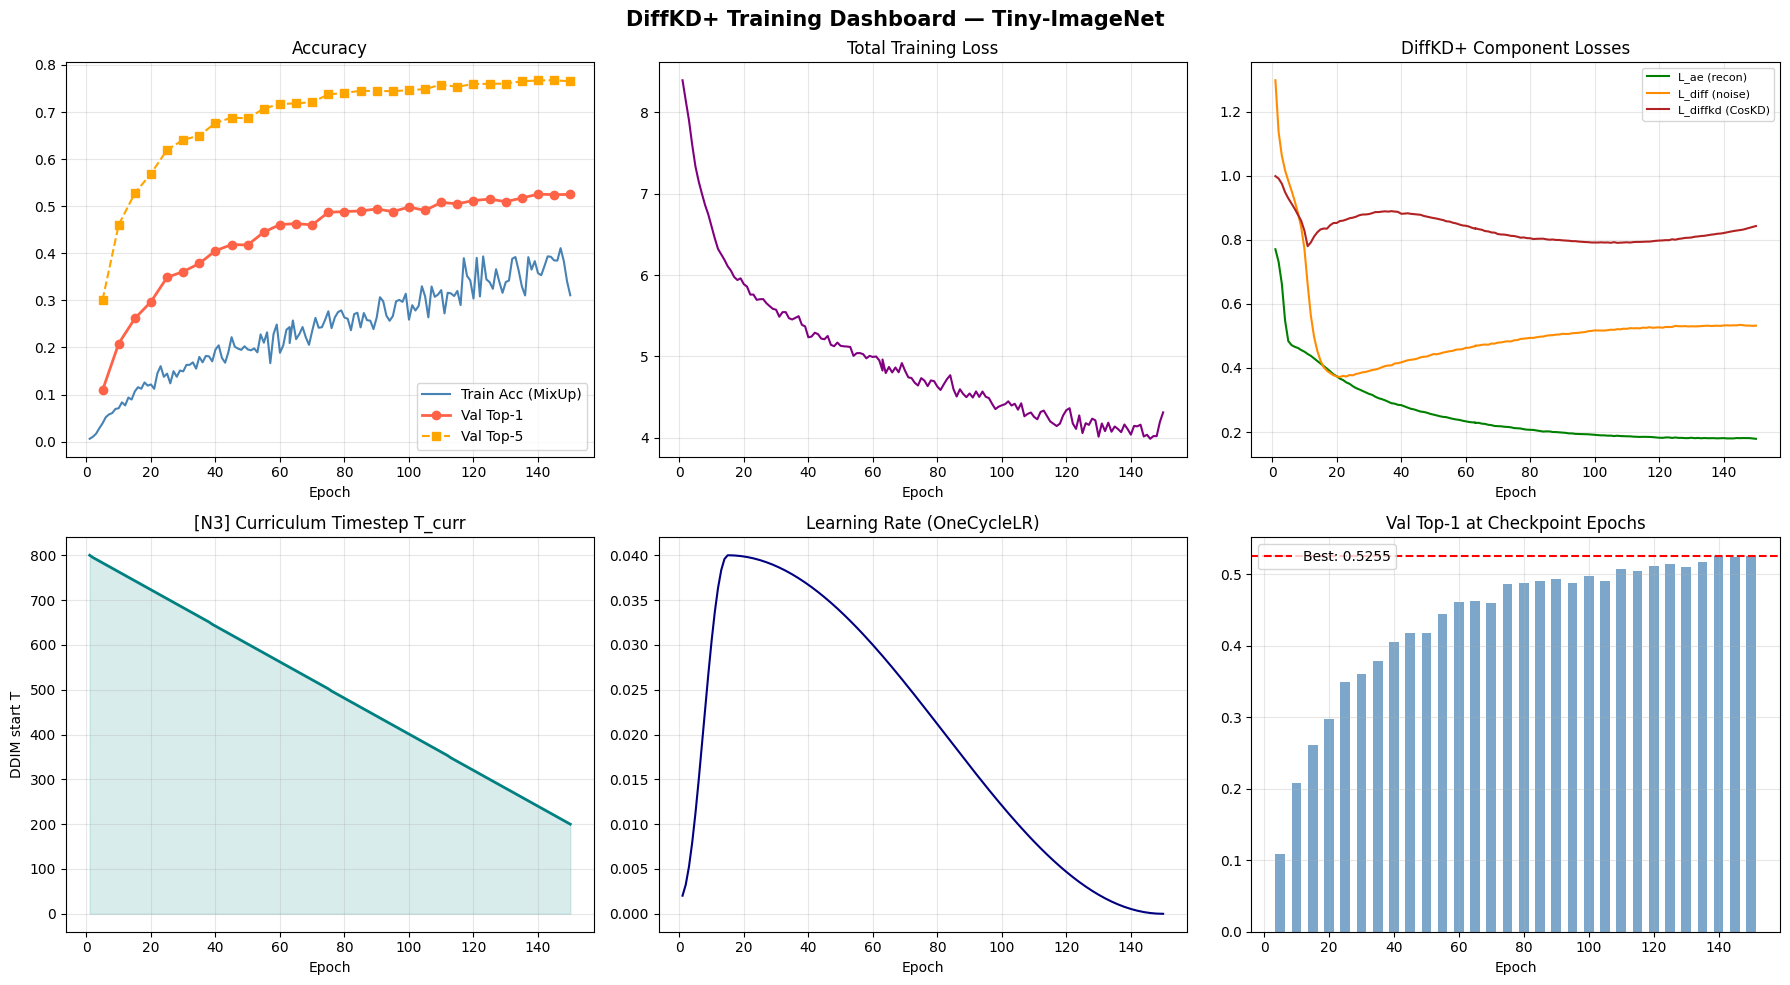

Dashboard saved: /kaggle/working/training_dashboard.png


In [16]:
df     = pd.read_csv(CSV_PATH)
df_val = df[df['val_top1'] > 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DiffKD+ Training Dashboard — Tiny-ImageNet',
             fontsize=15, fontweight='bold')

# 1. Accuracy curves
ax = axes[0, 0]
ax.plot(df['epoch'], df['train_acc'],
        label='Train Acc (MixUp)', color='steelblue', linewidth=1.5)
ax.plot(df_val['epoch'], df_val['val_top1'],
        label='Val Top-1', color='tomato', marker='o', linewidth=2)
ax.plot(df_val['epoch'], df_val['val_top5'],
        label='Val Top-5', color='orange', marker='s',
        linestyle='--', linewidth=1.5)
ax.set_title('Accuracy'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

# 2. Total loss
ax = axes[0, 1]
ax.plot(df['epoch'], df['train_loss'], color='purple', linewidth=1.5)
ax.set_title('Total Training Loss'); ax.set_xlabel('Epoch')
ax.grid(alpha=0.3)

# 3. Component losses
ax = axes[0, 2]
ax.plot(df['epoch'], df['L_ae'],     label='L_ae (recon)',     color='green')
ax.plot(df['epoch'], df['L_diff'],   label='L_diff (noise)',   color='darkorange')
ax.plot(df['epoch'], df['L_diffkd'], label='L_diffkd (CosKD)', color='firebrick')
ax.set_title('DiffKD+ Component Losses'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. N3 Curriculum timestep
ax = axes[1, 0]
ax.plot(df['epoch'], df['T_curr'], color='teal', linewidth=2)
ax.fill_between(df['epoch'], df['T_curr'], alpha=0.15, color='teal')
ax.set_title('[N3] Curriculum Timestep T_curr')
ax.set_xlabel('Epoch'); ax.set_ylabel('DDIM start T')
ax.grid(alpha=0.3)

# 5. Learning rate
ax = axes[1, 1]
ax.plot(df['epoch'], df['lr'], color='navy', linewidth=1.5)
ax.set_title('Learning Rate (OneCycleLR)')
ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

# 6. Val Top-1 bar + best line
ax = axes[1, 2]
ax.bar(df_val['epoch'], df_val['val_top1'],
       color='steelblue', alpha=0.7, width=3)
best = df_val['val_top1'].max()
ax.axhline(best, color='red', linestyle='--', linewidth=1.5,
           label=f"Best: {best:.4f}")
ax.set_title('Val Top-1 at Checkpoint Epochs')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
out_fig = os.path.join(WORKING_DIR, 'training_dashboard.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Dashboard saved: {out_fig}")

---
## Step 16 — Final Evaluation & Paper Comparison

In [17]:
# Load best checkpoint
best_ckpt = os.path.join(CKPT_DIR, 'best_model.pth')
if os.path.exists(best_ckpt):
    ckpt = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
    _student.load_state_dict(ckpt['student_state_dict'])
    print(f"Loaded best model from epoch {ckpt['epoch']}")

final_s1, final_s5, final_t1 = validate(student, teacher, val_loader)

gap_total  = final_t1 - 0.0          # teacher - untrained student floor
gap_closed = (final_s1 / final_t1) * 100 if final_t1 > 0 else 0

print("\n" + "="*58)
print("          FINAL EVALUATION — DiffKD+")
print("="*58)
print(f"  Teacher (ResNet-50, fine-tuned)  Top-1 : {final_t1:.4f}")
print(f"  Student (ResNet-34, DiffKD+)     Top-1 : {final_s1:.4f}")
print(f"  Student (ResNet-34, DiffKD+)     Top-5 : {final_s5:.4f}")
print(f"  Teacher–Student gap              : {final_t1 - final_s1:.4f}")
print(f"  Student / Teacher ratio          : {gap_closed:.1f}%")
print("="*58)
print("\n  Paper reference (full ImageNet, R34 teacher → R18 student):")
print("  Teacher: 73.31%   Student baseline: 69.76%   DiffKD: 72.22%")
print("  Gap closed: 84%")
print("\n  Note: Tiny-ImageNet (200 cls, 64px) ≠ full ImageNet.")
print("  The gap-closing ratio is the fair comparison metric.")
print("="*58)

Loaded best model from epoch 140



          FINAL EVALUATION — DiffKD+
  Teacher (ResNet-50, fine-tuned)  Top-1 : 0.6207
  Student (ResNet-34, DiffKD+)     Top-1 : 0.5255
  Student (ResNet-34, DiffKD+)     Top-5 : 0.7671
  Teacher–Student gap              : 0.0952
  Student / Teacher ratio          : 84.7%

  Paper reference (full ImageNet, R34 teacher → R18 student):
  Teacher: 73.31%   Student baseline: 69.76%   DiffKD: 72.22%
  Gap closed: 84%

  Note: Tiny-ImageNet (200 cls, 64px) ≠ full ImageNet.
  The gap-closing ratio is the fair comparison metric.
